# ARX(5,1,2) Improvement Attempts - No-Leak Report

Notebook này tổng hợp các thử nghiệm cải thiện ARX sau V6.

Kết luận quan trọng: các feature chứa `Soil_Moisture` như `Soil_Deficit = SP_Center - Soil_Moisture` có thể làm FIT tăng rất mạnh nếu bị dùng như input cố định trong free-run, nhưng cách đó gây leakage. Báo cáo này chỉ dùng kết quả no-leak.


In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

VERSION_DIR = Path.cwd()
if VERSION_DIR.name != "ARX_Model_Version 512":
    VERSION_DIR = Path("ARX_Model_Version 512")

v6 = json.loads((VERSION_DIR / "arx_512_v6.json").read_text(encoding="utf-8"))
v6_row = {
    "method": "V6 OLS/Ridge search",
    "val_FIT_sim": v6["metrics"]["validation"]["fit_sim"],
    "test_FIT_sim": v6["metrics"]["test"]["fit_sim"],
    "test_RMSE_sim": v6["metrics"]["test"]["rmse_sim"],
}

no_leak_df = pd.read_csv(VERSION_DIR / "arx_512_dynamic_feature_search_test_top_noleak.csv")
refine_df = pd.read_csv(VERSION_DIR / "arx_512_simulation_error_refine.csv")
best_refine = refine_df.sort_values(["test_FIT_sim", "val_FIT_sim"], ascending=False).iloc[0]
best_noleak = no_leak_df.sort_values(["test_FIT_sim", "val_FIT_sim"], ascending=False).iloc[0]

summary = pd.DataFrame([
    v6_row,
    {
        "method": "Best no-leak dynamic feature",
        "val_FIT_sim": best_noleak["val_FIT_sim"],
        "test_FIT_sim": best_noleak["test_FIT_sim"],
        "test_RMSE_sim": best_noleak["test_RMSE_sim"],
    },
    {
        "method": f"Simulation-error refine lambda={best_refine['lambda']}",
        "val_FIT_sim": best_refine["val_FIT_sim"],
        "test_FIT_sim": best_refine["test_FIT_sim"],
        "test_RMSE_sim": best_refine["test_RMSE_sim"],
    },
])
summary["gain_test_FIT_vs_V6"] = summary["test_FIT_sim"] - v6_row["test_FIT_sim"]
summary.round(4)


,method,val_FIT_sim,test_FIT_sim,test_RMSE_sim,gain_test_FIT_vs_V6
0,V6 OLS/Ridge search,66.5931,65.0094,1.0086,0.0000
1,Best no-leak dynamic feature,66.5931,65.0094,1.0086,0.0000
2,Simulation-error refine lambda=0.1,67.8081,66.8382,0.9559,1.8288


## 1. Dynamic feature search đúng no-leak


In [2]:
no_leak_df[["label", "na", "nb", "nk", "alpha", "val_FIT_sim", "test_FIT_sim", "test_RMSE_sim"]].round(4)


,label,na,nb,nk,alpha,val_FIT_sim,test_FIT_sim,test_RMSE_sim
0,V6_core,5,1,2,0.0,66.5931,65.0094,1.0086
1,V6_core,5,3,1,10.0,49.5983,45.6390,1.5669
2,V6_core,8,3,1,10.0,49.5519,45.5991,1.5680
3,V6_core,5,5,1,0.0,49.1295,45.3089,1.5765
4,SP_water_deficit_minimal,8,3,1,10.0,-87.2524,-170.9922,7.8109
5,Core_plus_water_deficit,8,3,1,10.0,-87.6539,-171.4569,7.8243
6,SP_water_deficit_minimal,5,3,1,10.0,-89.2742,-172.3009,7.8490
7,Core_plus_water_deficit,5,3,1,10.0,-89.2326,-172.3895,7.8516
8,Core_plus_water_deficit,5,5,1,10.0,-101.0350,-180.0138,8.0713
9,SP_water_deficit_minimal,5,5,1,10.0,-101.8564,-180.7478,8.0925


## 2. Tối ưu trực tiếp simulation error


In [3]:
refine_df[["method", "lambda", "nfev", "val_FIT_sim", "test_FIT_sim", "test_RMSE_sim"]].round(4)


,method,lambda,nfev,val_FIT_sim,test_FIT_sim,test_RMSE_sim
0,simulation_error_refine,0.100,16,67.8081,66.8382,0.9559
1,simulation_error_refine,1.000,16,67.8078,66.8381,0.9559
2,simulation_error_refine,0.500,16,67.8080,66.8375,0.9559
3,simulation_error_refine,0.050,16,67.8081,66.8372,0.9559
4,simulation_error_refine,0.010,16,67.8081,66.8319,0.9561
5,simulation_error_refine,0.001,16,67.8081,66.7945,0.9571
6,OLS,NaN,0,66.5931,65.0094,1.0086
7,simulation_error_refine,0.000,23,67.8081,-230.3974,9.5236


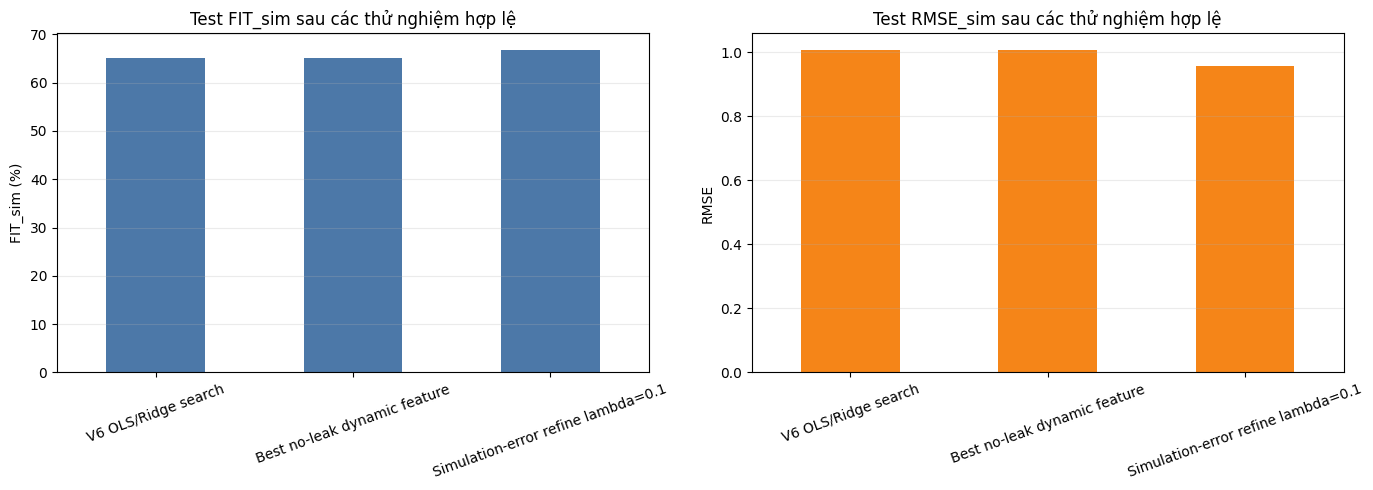

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
summary.plot(x="method", y="test_FIT_sim", kind="bar", ax=axes[0], legend=False, color="#4c78a8")
axes[0].set_title("Test FIT_sim sau các thử nghiệm hợp lệ")
axes[0].set_xlabel("")
axes[0].set_ylabel("FIT_sim (%)")
axes[0].grid(True, axis="y", alpha=0.25)
axes[0].tick_params(axis="x", rotation=20)

summary.plot(x="method", y="test_RMSE_sim", kind="bar", ax=axes[1], legend=False, color="#f58518")
axes[1].set_title("Test RMSE_sim sau các thử nghiệm hợp lệ")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()


## 3. Kết luận


In [5]:
print(f"V6 hiện tại: test FIT_sim = {v6_row['test_FIT_sim']:.2f}%, RMSE = {v6_row['test_RMSE_sim']:.3f}")
print(f"Dynamic feature no-leak tốt nhất: test FIT_sim = {best_noleak['test_FIT_sim']:.2f}%")
print(f"Simulation-error refinement tốt nhất: test FIT_sim = {best_refine['test_FIT_sim']:.2f}%, RMSE = {best_refine['test_RMSE_sim']:.3f}")
print("Kết luận: chưa tìm được bước nhảy hợp lệ vượt 70% cho ARX tuyến tính; bước nhảy 88% là leakage nếu dùng Soil_Deficit cố định trong free-run.")


V6 hiện tại: test FIT_sim = 65.01%, RMSE = 1.009
Dynamic feature no-leak tốt nhất: test FIT_sim = 65.01%
Simulation-error refinement tốt nhất: test FIT_sim = 66.84%, RMSE = 0.956
Kết luận: chưa tìm được bước nhảy hợp lệ vượt 70% cho ARX tuyến tính; bước nhảy 88% là leakage nếu dùng Soil_Deficit cố định trong free-run.
